In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Load & Preprocess Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from local file
df = pd.read_csv("cricket_data.csv")

In [ ]:
# Define numeric columns that need conversion
numeric_columns = ['Matches_Batted', 'Not_Outs', 'Runs_Scored', 'Balls_Faced', 'Batting_Strike_Rate', 
                   'Centuries', 'Half_Centuries', 'Fours', 'Sixes', 'Catches_Taken', 'Stumpings',
                   'Matches_Bowled', 'Balls_Bowled', 'Runs_Conceded', 'Wickets_Taken', 'Bowling_Average',
                   'Economy_Rate', 'Bowling_Strike_Rate', 'Four_Wicket_Hauls', 'Five_Wicket_Hauls']

# Ensure columns exist in DataFrame before applying conversion
existing_numeric_columns = [col for col in numeric_columns if col in df.columns]

# Replace 'No stats' with NaN before conversion
df[existing_numeric_columns] = df[existing_numeric_columns].replace("No stats", np.nan)

# Convert to numeric with coercion
df[existing_numeric_columns] = df[existing_numeric_columns].apply(pd.to_numeric, errors='coerce')

# Convert object columns that should be numeric
df['Batting_Average'] = pd.to_numeric(df['Batting_Average'], errors='coerce')
df['Highest_Score'] = pd.to_numeric(df['Highest_Score'].astype(str).str.replace('*', ''), errors='coerce')

# Handle missing values: Replace NaN with 0 or another appropriate method
df.fillna(0, inplace=True)

In [15]:
# Handling missing values
df.fillna(0, inplace=True)  # Replace NaN with 0 (or use appropriate strategies)


In [16]:
# Display basic info and first few rows
print(df.info())
print(df.head())

# Summary statistics
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 1008 non-null   float64
 1   Player_Name          1008 non-null   object 
 2   Matches_Batted       1008 non-null   float64
 3   Not_Outs             1008 non-null   float64
 4   Runs_Scored          1008 non-null   float64
 5   Highest_Score        1008 non-null   object 
 6   Batting_Average      1008 non-null   object 
 7   Balls_Faced          1008 non-null   float64
 8   Batting_Strike_Rate  1008 non-null   float64
 9   Centuries            1008 non-null   float64
 10  Half_Centuries       1008 non-null   float64
 11  Fours                1008 non-null   float64
 12  Sixes                1008 non-null   float64
 13  Catches_Taken        1008 non-null   float64
 14  Stumpings            1008 non-null   float64
 15  Matches_Bowled       1008 non-null   f

# Exploratory Data Analysis (EDA)

Runs Distribution

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


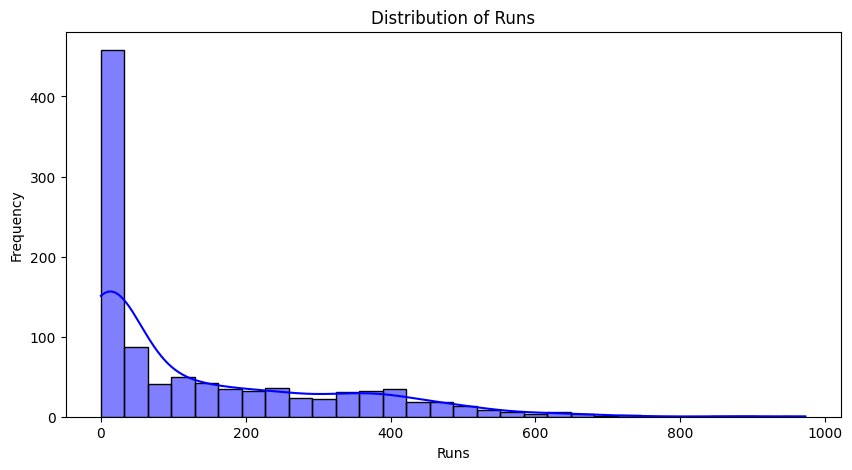

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Runs_Scored'], bins=30, kde=True, color='blue')
plt.title("Distribution of Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

 Batting Average vs Strike Rate

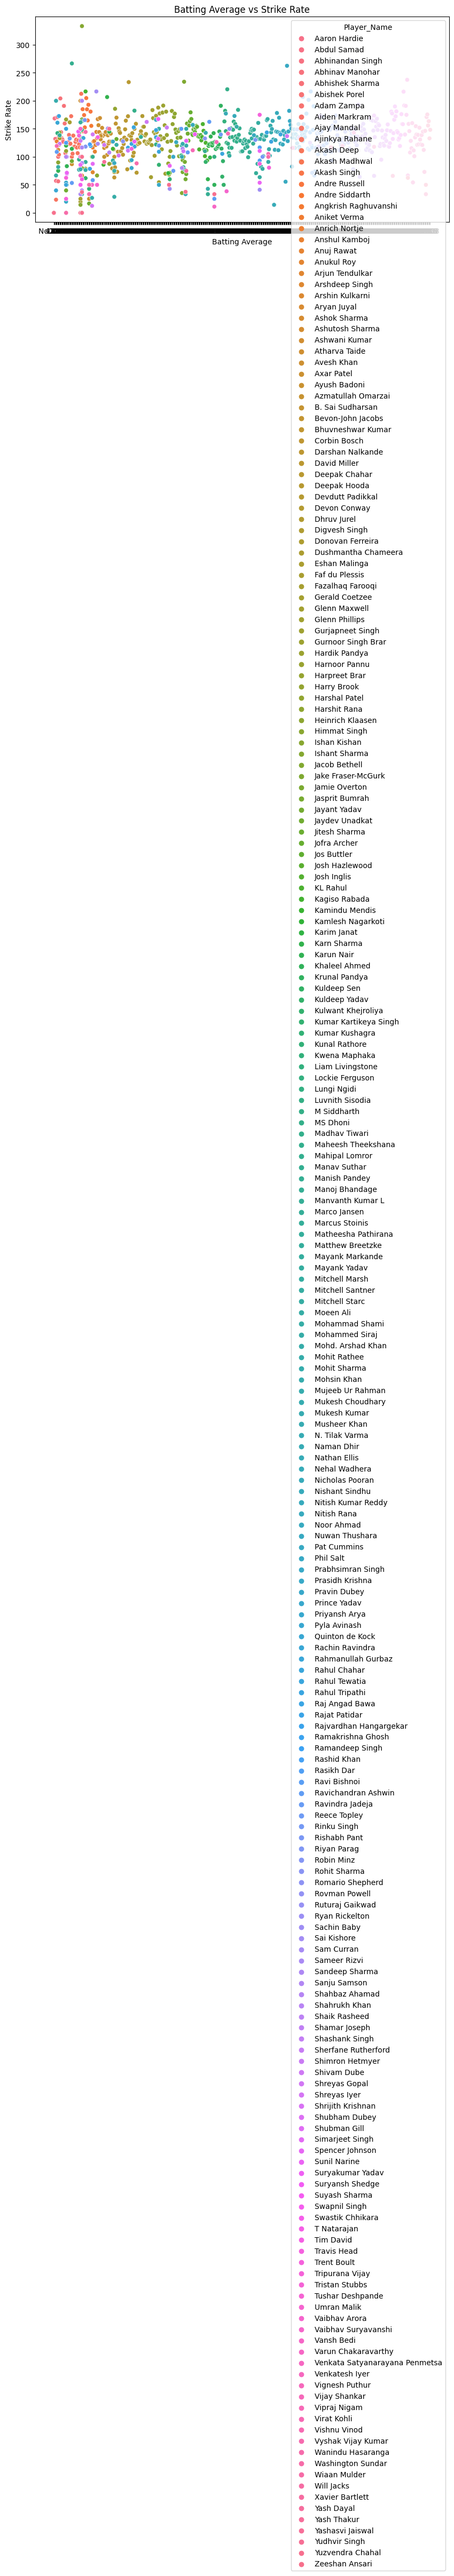

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Batting_Average'], y=df['Batting_Strike_Rate'], hue=df['Player_Name'])
plt.title("Batting Average vs Strike Rate")
plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.show()

Top 10 Run Scorers

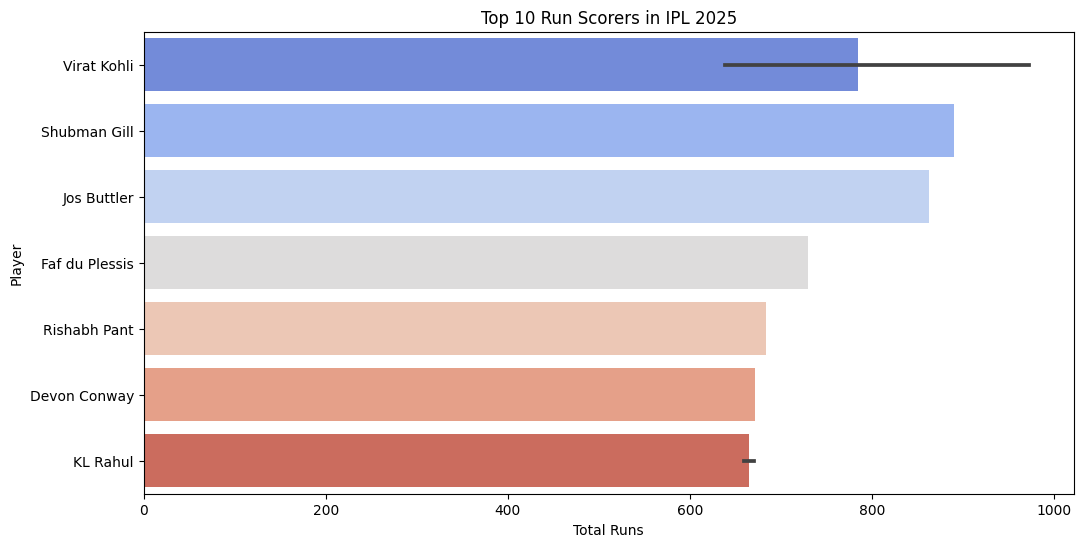

In [19]:
top_scorers = df.nlargest(10, 'Runs_Scored')
plt.figure(figsize=(12, 6))
sns.barplot(x='Runs_Scored', y='Player_Name', data=top_scorers, palette='coolwarm')
plt.title("Top 10 Run Scorers in IPL 2025")
plt.xlabel("Total Runs")
plt.ylabel("Player")
plt.show()

Bowling Economy Rate vs Wickets

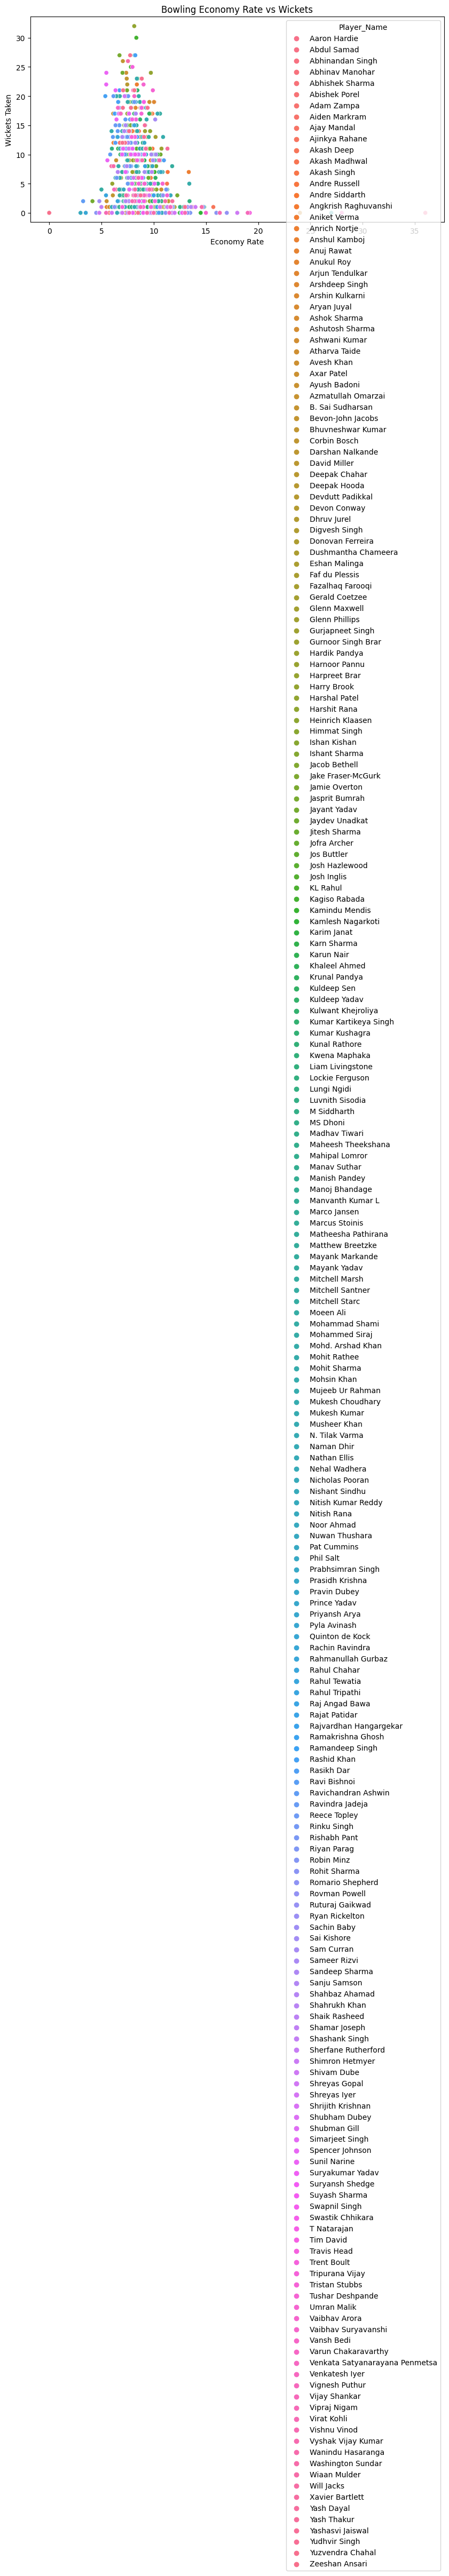

In [22]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Economy_Rate'], y=df['Wickets_Taken'], hue=df['Player_Name'])
plt.title("Bowling Economy Rate vs Wickets")
plt.xlabel("Economy Rate")
plt.ylabel("Wickets Taken")
plt.show()

Heatmap

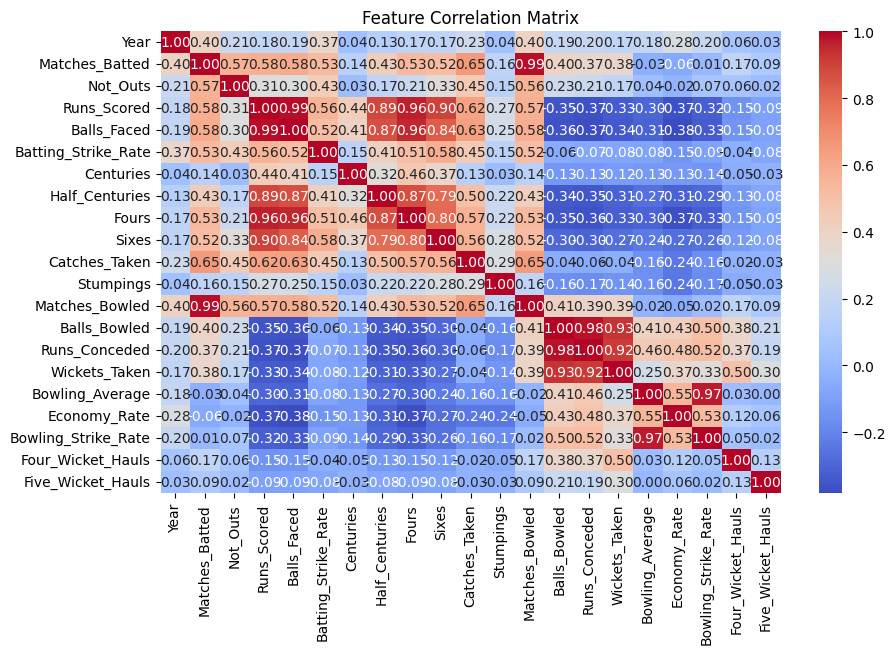

In [28]:
# Compute correlation only for numeric columns
numeric_df = df.select_dtypes(include=[np.number])  # Select only numeric columns

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()


# BDA

Top players based on performance

In [29]:
print("Top 5 players by Runs:")
print(df[['Player_Name', 'Runs_Scored']].sort_values(by='Runs_Scored', ascending=False).head())

print("Top 5 players by Wickets:")
print(df[['Player_Name', 'Wickets_Taken']].sort_values(by='Wickets_Taken', ascending=False).head())

print("Top 5 players by Strike Rate:")
print(df[['Player_Name', 'Batting_Strike_Rate']].sort_values(by='Batting_Strike_Rate', ascending=False).head())

Top 5 players by Runs:
        Player_Name  Runs_Scored
956     Virat Kohli        973.0
846    Shubman Gill        890.0
320     Jos Buttler        863.0
948     Virat Kohli        741.0
185  Faf du Plessis        730.0
Top 5 players by Wickets:
        Player_Name  Wickets_Taken
236   Harshal Patel           32.0
345   Kagiso Rabada           30.0
539    Mohit Sharma           27.0
664     Rashid Khan           27.0
282  Jasprit Bumrah           27.0
Top 5 players by Strike Rate:
          Player_Name  Batting_Strike_Rate
266     Ishant Sharma               333.33
750  Romario Shepherd               271.43
450    Mahipal Lomror               266.66
592       Pat Cummins               262.50
918       Umran Malik               237.50


Correlation between Batting Avg & Strike Rate

In [32]:
corr_value = df['Batting_Average'].corr(df['Batting_Strike_Rate'])
print(f"Correlation between Batting Average and Strike Rate: {corr_value:.2f}")

Correlation between Batting Average and Strike Rate: 0.69


# Predicting Performance Trends

Linear regression model to predict Runs Scored

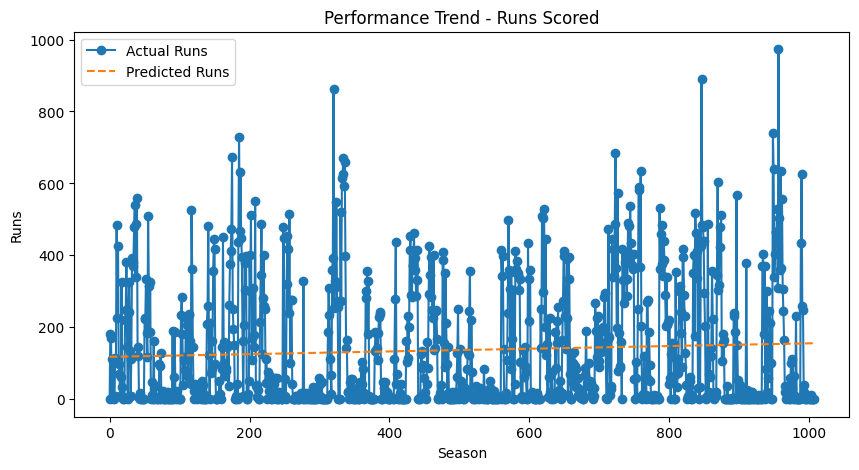

In [46]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import zscore

df['Season'] = df.index  # Assuming each row is a season-wise record
X = df[['Season']]
y = df['Runs_Scored']

model = LinearRegression()
model.fit(X, y)
df['Predicted_Runs'] = model.predict(X)

plt.figure(figsize=(10, 5))
plt.plot(df['Season'], df['Runs_Scored'], marker='o', label='Actual Runs')
plt.plot(df['Season'], df['Predicted_Runs'], linestyle='dashed', label='Predicted Runs')
plt.title("Performance Trend - Runs Scored")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.legend()
plt.show()

# Identifying Underrated Players

Z-score analysis

In [47]:
performance_cols = ['Runs_Scored', 'Wickets_Taken', 'Batting_Strike_Rate', 'Economy_Rate']
df['Z_Score'] = df[performance_cols].apply(zscore).mean(axis=1)
underrated_players = df[df['Z_Score'] < 0]

print("Underrated Players:")
print(underrated_players[['Player_Name', 'Z_Score']].sort_values(by='Z_Score'))


Underrated Players:
          Player_Name   Z_Score
0        Aaron Hardie -1.082215
1007   Zeeshan Ansari -1.082215
909   Tripurana Vijay -1.082215
537      Mohit Rathee -1.082215
576    Nishant Sindhu -1.082215
...               ...       ...
99         Avesh Khan -0.009499
951       Virat Kohli -0.009327
302    Jaydev Unadkat -0.008876
189    Faf du Plessis -0.006491
815   Shimron Hetmyer -0.000898

[475 rows x 2 columns]
